In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================

import pandas as pd
import numpy as np
import time
import warnings
from datetime import timedelta
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline
import torch

# Local data directory (use INF2006_Data_Students folder)
DATA_DIR = Path(__file__).parent / 'INF2006_Data_Students' if '__file__' in dir() else Path('.') / 'INF2006_Data_Students'
# Fallback: set explicitly if the above doesn't resolve correctly
if not DATA_DIR.exists():
    DATA_DIR = Path(r'c:\Users\Sebert\Desktop\SIT Lambert\Y2T2\INF2006 - Cloud Computing and Big Data\Project\Algorithmic Trading\INF2006_Data_Students')

warnings.filterwarnings('ignore')

# Configuration
STARTING_CASH = 100000
FINBERT_MODEL = "ProsusAI/finbert"
DEVICE = 0 if torch.cuda.is_available() else -1

print(f"Data directory: {DATA_DIR}")
print(f"Initial capital: ${STARTING_CASH:,.0f}")
print(f"Device: {'GPU' if DEVICE >= 0 else 'CPU'}")

# ── Cache setup ───────────────────────────────────────────────────────────
import pickle as _pickle

CACHE_DIR = Path('.') / 'cache'
CACHE_DIR.mkdir(exist_ok=True)

def _cache_save(obj, path):
    with open(path, 'wb') as f:
        _pickle.dump(obj, f)

def _cache_load(path):
    with open(path, 'rb') as f:
        return _pickle.load(f)

def _cache_exists(*paths):
    return all(Path(p).exists() for p in paths)

print(f"Cache directory: {CACHE_DIR.resolve()}")


c:\Users\alexi\anaconda3\envs\audio_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data directory: INF2006_Data_Students
Initial capital: $100,000
Device: GPU
Cache directory: D:\SIT\Uni\SIT_main\Y2T2\CloudComp\Project2\Algorithmic Trading\Trading-Strategy\cache


In [2]:
# ============================================================
# CELL 2: Initialize FinBERT
# ============================================================

print("Loading FinBERT (first run downloads ~420MB)...")

finbert_pipeline = pipeline(
    "sentiment-analysis",
    model=FINBERT_MODEL,
    tokenizer=FINBERT_MODEL,
    device=DEVICE,
    return_all_scores=True,
    truncation=True,
    max_length=512
)

print("FinBERT loaded.")

Loading FinBERT (first run downloads ~420MB)...



Device set to use cuda:0


FinBERT loaded.


In [3]:
# ============================================================
# CELL 3: Data Loading
# ============================================================

import shutil
import tempfile

def load_prices(split='dev'):
    filepath = DATA_DIR / f'prices_{split}.parquet'
    if not filepath.exists():
        raise FileNotFoundError(f"Not found: {filepath}")
    # Copy to short temp path to avoid Windows long-path issues
    tmp = Path(tempfile.gettempdir()) / f'prices_{split}.parquet'
    shutil.copy2(filepath, tmp)
    return pd.read_parquet(tmp)

def load_earnings(split='dev'):
    filepath = DATA_DIR / f'earnings_{split}.parquet'
    if not filepath.exists():
        raise FileNotFoundError(f"Not found: {filepath}")
    tmp = Path(tempfile.gettempdir()) / f'earnings_{split}.parquet'
    shutil.copy2(filepath, tmp)
    return pd.read_parquet(tmp)

prices_dev = load_prices('dev')
prices_val = load_prices('val')
earnings_dev = load_earnings('dev')
earnings_val = load_earnings('val')

print(f"Dev prices:   {len(prices_dev):,} records")
print(f"Val prices:   {len(prices_val):,} records")
print(f"Dev earnings: {len(earnings_dev):,} records")
print(f"Val earnings: {len(earnings_val):,} records")

Dev prices:   1,332,576 records
Val prices:   598,740 records
Dev earnings: 9,729 records
Val earnings: 8,534 records


In [4]:
# ============================================================
# CELL 6: Portfolio Class
# ============================================================

class Portfolio:
    def __init__(self, starting_cash=100000):
        self.cash = starting_cash
        self.positions = {}
        self.trades = []

    def buy_target(self, ticker, price, date, target_value=5000):
        if ticker in self.positions:
            return 0
        max_shares = int(target_value // price)
        if max_shares <= 0:
            return 0
        cost = min(max_shares * price, self.cash)
        shares = int(cost // price)
        if shares <= 0:
            return 0
        self.cash -= cost
        self.positions[ticker] = {'shares': shares, 'buy_price': price}
        self.trades.append({'date': date, 'ticker': ticker, 'action': 'BUY',
                          'shares': shares, 'price': price, 'value': cost})
        return shares

    def sell(self, ticker, price, date):
        if ticker not in self.positions:
            return 0
        position = self.positions[ticker]
        shares = position['shares']
        proceeds = shares * price
        del self.positions[ticker]
        self.cash += proceeds
        self.trades.append({'date': date, 'ticker': ticker, 'action': 'SELL',
                          'shares': shares, 'price': price, 'value': proceeds})
        return shares

    def get_value(self, current_prices):
        total = self.cash
        for ticker, pos in self.positions.items():
            if ticker in current_prices:
                total += pos['shares'] * current_prices[ticker]
        return total

    def get_state(self, current_prices):
        return {
            'cash': self.cash,
            'positions': {t: {'shares': p['shares'], 'buy_price': p['buy_price']}
                         for t, p in self.positions.items()},
            'total_value': self.get_value(current_prices)
        }

print("Portfolio class loaded")

Portfolio class loaded


In [5]:
# ============================================================
# CELL 7: Trading Simulation
# ============================================================

class TradingSimulation:
    def __init__(self, prices, earnings, starting_cash=100000, cache_key=None):
        self.prices = prices
        self.earnings = earnings
        self.portfolio = Portfolio(starting_cash)
        self.weekly_schedule = self._create_weekly_schedule()

        # Cache sim lookups (prices_by_ticker_date, price_history, earnings_by_ticker_week)
        # These are built via iterrows — slow for large datasets. Cache by split name.
        _sim_cache = (CACHE_DIR / f'sim_lookups_{cache_key}.pkl') if cache_key else None
        if _sim_cache and _sim_cache.exists():
            _d = _cache_load(_sim_cache)
            self.prices_by_ticker_date   = _d['ptd']
            self.price_history           = _d['ph']
            self.earnings_by_ticker_week = _d['etw']
            print(f'  [CACHE] Sim lookups loaded ({cache_key})')
        else:
            self._build_lookups()
            self._build_price_history()
            if _sim_cache:
                _cache_save({'ptd': self.prices_by_ticker_date,
                             'ph':  self.price_history,
                             'etw': self.earnings_by_ticker_week}, _sim_cache)
                print(f'  [CACHE] Sim lookups saved ({cache_key})')

    def _create_weekly_schedule(self):
        min_date = pd.to_datetime(self.prices['date']).min()
        max_date = pd.to_datetime(self.prices['date']).max()
        return pd.date_range(start=min_date, end=max_date, freq='W-FRI').strftime('%Y-%m-%d').tolist()

    def _build_lookups(self):
        # Pre-compute O(1) lookup dictionaries
        # IMPORTANT: Convert dates to strings for consistent matching
        self.prices_by_ticker_date = {}
        for ticker in self.prices['ticker'].unique():
            ticker_prices = self.prices[self.prices['ticker'] == ticker].sort_values('date')
            for _, row in ticker_prices.iterrows():
                # Convert date to string for consistent lookup
                date_str = row['date'] if isinstance(row['date'], str) else pd.to_datetime(row['date']).strftime('%Y-%m-%d')
                self.prices_by_ticker_date[(ticker, date_str)] = row['close']

        self.earnings_by_ticker_week = {}
        for ticker in self.earnings['ticker'].unique():
            ticker_earnings = self.earnings[self.earnings['ticker'] == ticker].sort_values('date')
            for _, row in ticker_earnings.iterrows():
                earnings_date = pd.to_datetime(row['date'])
                week_end = (earnings_date + timedelta (days=(4 - earnings_date.weekday()) % 7)).strftime('%Y-%m-%d')
                self.earnings_by_ticker_week[(ticker, week_end)] = row['transcript']

    def _build_price_history(self):
        """Build price history for each ticker to enable fallback to most recent price."""
        self.price_history = {}
        for ticker in self.prices['ticker'].unique():
            ticker_prices = self.prices[self.prices['ticker'] == ticker].sort_values('date')
            # Store as list of (date_string, price) tuples
            self.price_history[ticker] = [
                (row['date'] if isinstance(row['date'], str) else pd.to_datetime(row['date']).strftime('%Y-%m-%d'), row['close'])
                for _, row in ticker_prices.iterrows()
            ]

    def _get_price_on_date(self, ticker, date):
        """Get price for ticker on specific date, with fallback to most recent price."""
        # Try direct lookup first
        direct = self.prices_by_ticker_date.get((ticker, date))
        if direct is not None:
            return direct

        # Fallback: find most recent price before this date
        if ticker in self.price_history:
            for hist_date, price in reversed(self.price_history[ticker]):
                if hist_date <= date:
                    return price

        return None

    def _get_current_prices(self, date):
        """Get current prices for all tickers, with fallback to most recent prices."""
        current_prices = {}
        for ticker in self.prices['ticker'].unique():
            price = self._get_price_on_date(ticker, date)
            if price is not None:
                current_prices[ticker] = price
        return current_prices

    def _get_recent_earnings(self, ticker, current_date, days_lookback=7):
        return self.earnings_by_ticker_week.get((ticker, current_date))

    def run(self, strategy_function, analytics_lookup, verbose=False):
        portfolio_history = []
        all_tickers = sorted(self.prices['ticker'].unique())

        for i, week_date in enumerate(self.weekly_schedule):
            if verbose and i % 10 == 0:
                print(f"  Week {i+1}/{len(self.weekly_schedule)}: {week_date}")

            current_prices = self._get_current_prices(week_date)
            portfolio_state = self.portfolio.get_state(current_prices)

            for ticker in all_tickers:
                transcript = self._get_recent_earnings(ticker, week_date)

                ticker_data = analytics_lookup.get(ticker, [])
                latest_analytics = None
                for analytics_date, analytics_dict in ticker_data:
                    if analytics_date <= week_date:
                        latest_analytics = analytics_dict
                    else:
                        break
                if latest_analytics is None:
                    continue

                decision = strategy_function(ticker, week_date, transcript, portfolio_state, latest_analytics)
                price = self._get_price_on_date(ticker, week_date)
                if price is None:
                    continue

                if decision == 'BUY':
                    self.portfolio.buy_target(ticker, price, week_date, target_value=5000)
                elif decision == 'SELL':
                    self.portfolio.sell(ticker, price, week_date)

            portfolio_history.append({
                'date': week_date,
                'portfolio_value': self.portfolio.get_value(current_prices),
                'cash': self.portfolio.cash,
                'positions': len(self.portfolio.positions)
            })

        final_date = self.weekly_schedule[-1]
        final_prices = self._get_current_prices(final_date)
        return {
            'trades': self.portfolio.trades,
            'portfolio_history': portfolio_history,
            'final_portfolio': self.portfolio.get_state(final_prices),
            'final_prices': final_prices
        }

print("TradingSimulation class loaded")

TradingSimulation class loaded


In [6]:
# ============================================================
# CELL 8: Performance Metrics & Visualization
# ============================================================

def calculate_metrics(results, starting_cash=STARTING_CASH):
    """Calculate comprehensive performance metrics."""
    history_df = pd.DataFrame(results['portfolio_history'])
    history_df['date'] = pd.to_datetime(history_df['date'])
    trades_df = pd.DataFrame(results['trades'])

    final_value = results['final_portfolio']['total_value']
    total_return = (final_value - starting_cash) / starting_cash

    history_df['daily_return'] = history_df['portfolio_value'].pct_change()

    mean_daily_return = history_df['daily_return'].mean()
    std_daily_return = history_df['daily_return'].std()
    sharpe_ratio = (mean_daily_return / std_daily_return * np.sqrt(252)) if std_daily_return > 0 else 0

    peak = history_df['portfolio_value'].cummax()
    drawdown = (history_df['portfolio_value'] - peak) / peak
    max_drawdown = drawdown.min()

    if len(trades_df) > 0:
        buy_trades = trades_df[trades_df['action'] == 'BUY']
        sell_trades = trades_df[trades_df['action'] == 'SELL']
        profitable_trades = 0
        total_trades = 0
        for _, sell in sell_trades.iterrows():
            buy = buy_trades[buy_trades['ticker'] == sell['ticker']]
            buy = buy[buy['date'] < sell['date']]
            if len(buy) > 0:
                buy = buy.iloc[-1]
                if sell['value'] > buy['value']:
                    profitable_trades += 1
                total_trades += 1
        win_rate = profitable_trades / total_trades if total_trades > 0 else 0
    else:
        win_rate = 0

    volatility = std_daily_return * np.sqrt(252) if std_daily_return > 0 else 0

    return {
        'total_return': total_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'volatility': volatility,
        'num_trades': len(trades_df),
        'final_positions': len(results['final_portfolio']['positions'])
    }


def plot_results(results, metrics, title="Strategy Results", starting_cash=STARTING_CASH):
    """Generate visualization plots for strategy results."""
    history_df = pd.DataFrame(results['portfolio_history'])
    history_df['date'] = pd.to_datetime(history_df['date'])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Portfolio value
    axes[0, 0].plot(history_df['date'], history_df['portfolio_value'], linewidth=2, color='#2E86AB')
    axes[0, 0].axhline(y=starting_cash, color='r', linestyle='--', alpha=0.5, label='Starting Capital')
    axes[0, 0].set_title('Portfolio Value')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Value ($)')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    # Cash
    axes[0, 1].plot(history_df['date'], history_df['cash'], color='#22C55E', linewidth=2)
    axes[0, 1].set_title('Cash Position')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    # Positions
    axes[0, 2].plot(history_df['date'], history_df['positions'], color='#9467BE', linewidth=2)
    axes[0, 2].set_title('Number of Positions')
    axes[0, 2].set_xlabel('Date')
    axes[0, 2].grid(True, alpha=0.3)

    # Drawdown
    peak = history_df['portfolio_value'].cummax()
    drawdown = (history_df['portfolio_value'] - peak) / peak * 100
    axes[1, 0].fill_between(history_df['date'], drawdown, 0, color='#E15759', alpha=0.3)
    axes[1, 0].plot(history_df['date'], drawdown, color='#E15759', linewidth=1)
    axes[1, 0].set_title('Drawdown %')
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].grid(True, alpha=0.3)

    # Daily returns distribution - filter out inf and NaN values
    daily_returns = history_df['portfolio_value'].pct_change().dropna() * 100
    # Filter out infinite and extreme values that can occur when portfolio goes to zero
    daily_returns = daily_returns[np.isfinite(daily_returns)]
    daily_returns = daily_returns[daily_returns > -100]  # Remove -100% (total loss) outliers for cleaner histogram
    if len(daily_returns) > 0:
        axes[1, 1].hist(daily_returns, bins=30, edgecolor='black', alpha=0.7, color='#4DB6AC')
    axes[1, 1].set_title('Weekly Returns Distribution')
    axes[1, 1].set_xlabel('Return (%)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axvline(x=0, color='black', linestyle='-', alpha=0.3)

    # Rolling returns - also filter out inf values
    rolling_return = history_df['portfolio_value'].pct_change(periods=20).dropna() * 100
    rolling_return = rolling_return[np.isfinite(rolling_return)]
    axes[1, 2].plot(history_df['date'][:len(rolling_return)], rolling_return, linewidth=2, color='#FF9845')
    axes[1, 2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1, 2].set_title('20-Week Rolling Return')
    axes[1, 2].set_xlabel('Date')
    axes[1, 2].set_ylabel('Return (%)')
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_comparison(results_baseline, metrics_baseline, results_enhanced, metrics_enhanced, starting_cash=STARTING_CASH):
    """Plot side-by-side comparison of baseline vs enhanced strategy."""
    baseline_df = pd.DataFrame(results_baseline['portfolio_history'])
    baseline_df['date'] = pd.to_datetime(baseline_df['date'])
    baseline_df['strategy'] = 'Baseline'

    enhanced_df = pd.DataFrame(results_enhanced['portfolio_history'])
    enhanced_df['date'] = pd.to_datetime(enhanced_df['date'])
    enhanced_df['strategy'] = 'Enhanced'

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Baseline vs Enhanced Strategy Comparison', fontsize=16, fontweight='bold')

    # Portfolio Value Over Time
    axes[0, 0].plot(baseline_df['date'], baseline_df['portfolio_value'], linewidth=2, label='Baseline', color='#E15759', alpha=0.8)
    axes[0, 0].plot(enhanced_df['date'], enhanced_df['portfolio_value'], linewidth=2, label='Enhanced', color='#2E86AB', alpha=0.8)
    axes[0, 0].axhline(y=starting_cash, color='gray', linestyle='--', alpha=0.5, label='Starting Capital')
    axes[0, 0].set_title('Portfolio Value Over Time')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Portfolio Value ($)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    # Drawdown Comparison
    peak_baseline = baseline_df['portfolio_value'].cummax()
    drawdown_baseline = (baseline_df['portfolio_value'] - peak_baseline) / peak_baseline * 100
    peak_enhanced = enhanced_df['portfolio_value'].cummax()
    drawdown_enhanced = (enhanced_df['portfolio_value'] - peak_enhanced) / peak_enhanced * 100

    axes[0, 1].fill_between(baseline_df['date'], drawdown_baseline, 0, color='#E15759', alpha=0.3, label='Baseline')
    axes[0, 1].plot(baseline_df['date'], drawdown_baseline, color='#E15759', linewidth=1, alpha=0.7)
    axes[0, 1].fill_between(enhanced_df['date'], drawdown_enhanced, 0, color='#2E86AB', alpha=0.3, label='Enhanced')
    axes[0, 1].plot(enhanced_df['date'], drawdown_enhanced, color='#2E86AB', linewidth=1, alpha=0.7)
    axes[0, 1].set_title('Drawdown Comparison (%)')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('Drawdown %')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Metrics Comparison Bar Chart
    metrics_names = ['Total Return', 'Sharpe Ratio', 'Win Rate', 'Max Drawdown']
    baseline_values = [
        metrics_baseline['total_return'] * 100,
        metrics_baseline['sharpe_ratio'],
        metrics_baseline['win_rate'] * 100,
        abs(metrics_baseline['max_drawdown']) * 100
    ]
    enhanced_values = [
        metrics_enhanced['total_return'] * 100,
        metrics_enhanced['sharpe_ratio'],
        metrics_enhanced['win_rate'] * 100,
        abs(metrics_enhanced['max_drawdown']) * 100
    ]

    x = np.arange(len(metrics_names))
    width = 0.35

    bars1 = axes[1, 0].bar(x - width/2, baseline_values, width, label='Baseline', color='#E15759', alpha=0.8)
    bars2 = axes[1, 0].bar(x + width/2, enhanced_values, width, label='Enhanced', color='#2E86AB', alpha=0.8)
    axes[1, 0].set_title('Key Metrics Comparison')
    axes[1, 0].set_ylabel('Value')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(metrics_names, rotation=15, ha='right')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    axes[1, 0].axhline(y=0, color='black', linestyle='-', alpha=0.3)

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.1f}', ha='center', va='bottom', fontsize=8)

    # Number of Positions Over Time
    axes[1, 1].plot(baseline_df['date'], baseline_df['positions'], linewidth=2, label='Baseline', color='#E15759', alpha=0.8)
    axes[1, 1].plot(enhanced_df['date'], enhanced_df['positions'], linewidth=2, label='Enhanced', color='#2E86AB', alpha=0.8)
    axes[1, 1].set_title('Number of Positions Over Time')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Number of Positions')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def print_detailed_comparison(baseline_metrics, enhanced_metrics):
    """Print detailed metrics comparison table with improvement indicators."""
    print("\n" + "="*70)
    print("PERFORMANCE COMPARISON")
    print("="*70)

    print(f"{'Metric':<20} {'Baseline':<15} {'Enhanced':<15} {'Improvement':<15}")
    print(f"{'-'*70}")

    # Total Return
    return_diff = enhanced_metrics['return'] - baseline_metrics['return']
    return_arrow = "↑" if return_diff > 0 else "↓"
    print(f"{'Total Return':<20} {baseline_metrics['return']:>13.2%} {enhanced_metrics['return']:>13.2%} {return_arrow} {abs(return_diff):>+9.2%}")

    # Sharpe Ratio
    sharpe_diff = enhanced_metrics['sharpe'] - baseline_metrics['sharpe']
    sharpe_arrow = "↑" if sharpe_diff > 0 else "↓"
    print(f"{'Sharpe Ratio':<20} {baseline_metrics['sharpe']:>13.2f} {enhanced_metrics['sharpe']:>13.2f} {sharpe_arrow} {abs(sharpe_diff):>+9.2f}")

    # Max Drawdown (lower is better, so arrow direction flips)
    drawdown_diff = enhanced_metrics['drawdown'] - baseline_metrics['drawdown']
    drawdown_arrow = "↓" if drawdown_diff > 0 else "↑"
    print(f"{'Max Drawdown':<20} {baseline_metrics['drawdown']:>13.2%} {enhanced_metrics['drawdown']:>13.2%} {drawdown_arrow} {abs(drawdown_diff):>+9.2%}")

    # Win Rate
    winrate_diff = enhanced_metrics['win_rate'] - baseline_metrics['win_rate']
    winrate_arrow = "↑" if winrate_diff > 0 else "↓"
    print(f"{'Win Rate':<20} {baseline_metrics['win_rate']:>13.2%} {enhanced_metrics['win_rate']:>13.2%} {winrate_arrow} {abs(winrate_diff):>+9.2%}")

    # Volatility (lower is better for same return)
    volatility_diff = enhanced_metrics['volatility'] - baseline_metrics['volatility']
    volatility_arrow = "↓" if volatility_diff > 0 else "↑"
    print(f"{'Volatility':<20} {baseline_metrics['volatility']:>13.2%} {enhanced_metrics['volatility']:>13.2%} {volatility_arrow} {abs(volatility_diff):>+9.2%}")

    # Total Trades
    trades_diff = enhanced_metrics['trades'] - baseline_metrics['trades']
    trades_arrow = "↑" if trades_diff > 0 else "↓"
    print(f"{'Total Trades':<20} {baseline_metrics['trades']:>13d} {enhanced_metrics['trades']:>13d} {trades_arrow} {abs(trades_diff):>+9d}")

    print("="*70)

In [7]:
# ============================================================
# CELL 9: Strategy Base Class
# ============================================================

class BaseStrategy:
    def __init__(self, finbert_pipeline=None):
        self.finbert_pipeline = finbert_pipeline
        self.llm_cache = {}
        self.llm_cache_hits = 0
        self.llm_cache_misses = 0
        self.prices = None
        self.earnings = None

    def set_data(self, prices_df, earnings_df):
        """
        Set and preprocess data for evaluation.
        Call this before evaluate().
        """
        print("Cleaning and preprocessing data...")
        self.prices, self.earnings = self.clean_data(prices_df, earnings_df)
        print(f"Data ready: {len(self.prices):,} price records")

    def clean_data(self, prices_df, earnings_df):
        """Clean and validate data. Override for enhanced cleaning."""
        prices = prices_df.copy().drop_duplicates()
        earnings = earnings_df.copy().drop_duplicates()
        prices['date'] = pd.to_datetime(prices['date'])
        earnings['date'] = pd.to_datetime(earnings['date'])
        earnings = earnings[earnings['transcript'].str.len() > 100]
        return prices, earnings

    def calculate_analytics(self, prices_df):
        """Calculate technical indicators. Override for enhanced analytics."""
        print("Computing technical indicators (MA-50)...")
        results = []
        for ticker in prices_df['ticker'].unique():
            df = prices_df[prices_df['ticker'] == ticker].copy().sort_values('date')
            df['ma_50'] = df['close'].rolling(50, min_periods=1).mean()
            results.append(df[['ticker', 'date', 'ma_50', 'close']])
        result_df = pd.concat(results, ignore_index=True)
        result_df['date'] = result_df['date'].dt.strftime('%Y-%m-%d')
        print(f"Technical indicators computed: {len(result_df):,} rows")
        return result_df

    def llm_analysis(self, ticker, transcript, date):
        """Extract sentiment from earnings. Override for enhanced NLP."""
        if transcript is None or self.finbert_pipeline is None:
            return None

        # Use last 2000 characters of transcript
        text = transcript[-2000:] if len(transcript) > 2000 else transcript

        try:
            results = self.finbert_pipeline(text)
            # FinBERT returns sentiment classification
            sentiment = results[0][0]['label']  # 'positive', 'negative', or 'neutral'
            return {'sentiment': sentiment}
        except:
            return None

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        """
        Make trading decision. Override for enhanced logic.

        BASELINE STRATEGY:
        - Entry: Price > MA-50 AND (no earnings OR positive sentiment)
        - Exit: Price < MA-50 OR stop-loss at 20%
        """
        price = analytics.get('close', 0)
        ma_50 = analytics.get('ma_50', 0)
        has_position = ticker in portfolio_state.get('positions', {})

        sentiment = self.llm_analysis(ticker, transcript, date)

        if has_position:
            position = portfolio_state['positions'][ticker]
            buy_price = position['buy_price']

            # STOP-LOSS: Cut losses at 20% to prevent catastrophic losses
            if buy_price > 0:
                pnl_pct = (price - buy_price) / buy_price
                if pnl_pct < -0.20:
                    return 'SELL'

            # Normal exit: Price below MA-50
            return 'SELL' if price < ma_50 else 'HOLD'
        else:
            # Entry: Price above MA-50 AND (no earnings OR positive sentiment)
            if price > ma_50:
                if sentiment is None or sentiment['sentiment'] == 'positive':
                    return 'BUY'
        return 'HOLD'

    def _build_analytics_lookup(self, analytics_df):
        lookup = defaultdict(list)
        for _, row in analytics_df.iterrows():
            lookup[row['ticker']].append((row['date'], row.to_dict()))
        for ticker in lookup:
            lookup[ticker].sort(key=lambda x: x[0])
        return lookup

    def evaluate(self, verbose=False):
        """Evaluate strategy on previously set data."""
        if self.prices is None or self.earnings is None:
            raise ValueError("Must call set_data() before evaluate()")

        print("Running evaluation...")

        # Calculate analytics
        analytics = self.calculate_analytics(self.prices)
        analytics_lookup = self._build_analytics_lookup(analytics)

        # Run backtest
        print("Running backtest simulation...")
        sim = TradingSimulation(self.prices, self.earnings, STARTING_CASH)
        results = sim.run(
            lambda t, d, tr, ps, a: self.make_decision(t, d, tr, ps, a),
            analytics_lookup, verbose
        )

        return results

print("BaseStrategy class loaded")

BaseStrategy class loaded


In [8]:
# ============================================================
# CELL 10: Evaluation Helper Function
# ============================================================

def run_evaluation(baseline_strategy=None, enhanced_strategy=None, strategy='baseline', split='val'):
    """
    Helper function to load data and evaluate strategies.

    Args:
        baseline_strategy: BaseStrategy instance (required if strategy='baseline')
        enhanced_strategy: EnhancedStrategy instance (required if strategy='enhanced')
        strategy: 'baseline' or 'enhanced'
        split: 'dev', 'val', or 'test'

    Returns:
        results: Dictionary with trades, portfolio_history, final_portfolio
    """
    if strategy == 'baseline':
        if baseline_strategy is None:
            raise ValueError("baseline_strategy must be provided when strategy='baseline'")
        selected_strategy = baseline_strategy
    elif strategy == 'enhanced':
        if enhanced_strategy is None:
            raise ValueError("enhanced_strategy must be provided when strategy='enhanced'")
        selected_strategy = enhanced_strategy
    else:
        raise ValueError(f"strategy must be 'baseline' or 'enhanced', got '{strategy}'")

    # Load data
    print(f"Loading {split.upper()} split data...")
    prices = load_prices(split)
    earnings = load_earnings(split)

    # Set data and evaluate
    selected_strategy.set_data(prices, earnings)
    results = selected_strategy.evaluate()

    return results

print("Evaluation helper function loaded")


Evaluation helper function loaded


In [9]:
# # ============================================================
# # CELL 11: Baseline Strategy Evaluation
# # ============================================================
# #
# # This cell establishes the baseline performance on the validation split.
# #
# # IMPORTANT: Data Split Explanation
# # --------------------------------
# # - **Dev Split (2000-2019)**: For experimentation and hyperparameter tuning
# #   - Use this split to iterate on your strategy
# #   - Test different RSI periods, stop-loss levels, signal thresholds, etc.
# #
# # - **Val Split (2020-2024)**: For final performance reporting
# #   - This is the "test" set for comparing strategies
# #   - Do NOT tune hyperparameters on this split
# #   - Report your final metrics on this split
# #
# # Workflow:
# #   1. Run baseline on val split (establishes reference performance)
# #   2. Develop your enhanced strategy, tune on dev split
# #   3. Run final comparison on val split

# print("\n" + "="*70)
# print("BASELINE STRATEGY EVALUATION")
# print("="*70)

# # Create baseline strategy instance (no data loaded yet)
# baseline = BaseStrategy(finbert_pipeline)

# # Evaluate on Validation split (final performance reporting)
# print("\n[VAL SPLIT - Final Performance]")
# results_baseline_val = run_evaluation(baseline_strategy=baseline, strategy='baseline', split='val')

# metrics_baseline_val = calculate_metrics(results_baseline_val)
# BASELINE_METRICS_VAL = {
#     'return': metrics_baseline_val['total_return'],
#     'sharpe': metrics_baseline_val['sharpe_ratio'],
#     'drawdown': metrics_baseline_val['max_drawdown'],
#     'win_rate': metrics_baseline_val['win_rate'],
#     'volatility': metrics_baseline_val['volatility'],
#     'trades': metrics_baseline_val['num_trades']
# }

# print(f"Return: {BASELINE_METRICS_VAL['return']:.2%}")
# print(f"Sharpe: {BASELINE_METRICS_VAL['sharpe']:.2f}")
# print(f"Max Drawdown: {BASELINE_METRICS_VAL['drawdown']:.2%}")
# print(f"Win Rate: {BASELINE_METRICS_VAL['win_rate']:.1%}")
# print(f"Volatility: {BASELINE_METRICS_VAL['volatility']:.2%}")
# print(f"Total Trades: {BASELINE_METRICS_VAL['trades']:,}")

# print("\n" + "="*70)
# print("BASELINE METRICS STORED")
# print("="*70)
# print("Baseline metrics saved to BASELINE_METRICS_VAL for comparison.")
# print("="*70)

# # Visualization
# plot_results(results_baseline_val, metrics_baseline_val, title="Baseline Strategy - Validation Split")

# # ============================================================
# # OPTIONAL: Dev Split Evaluation (For Experimentation)
# # ============================================================
# # Uncomment below to evaluate baseline on dev split for experimentation
# #
# print("\n[DEV SPLIT - For Experimentation]")
# results_baseline_dev = run_evaluation(baseline_strategy=baseline, strategy='baseline', split='dev')
# metrics_baseline_dev = calculate_metrics(results_baseline_dev)
# print(f"Return: {metrics_baseline_dev['total_return']:.2%}")
# print(f"Sharpe: {metrics_baseline_dev['sharpe_ratio']:.2f}")
# print(f"Max Drawdown: {metrics_baseline_dev['max_drawdown']:.2%}")

# # Visualization
# plot_results(results_baseline_dev, metrics_baseline_dev, title="Baseline Strategy - Dev Split")

In [10]:
"""
Strategy Import Reference
=========================
Notebook Header                                                          -> File
-----------------------------------------------------------------------------------------
Enchanced Strat   (20MA Crossover w hard stop loss)                      -> v1_louvain_cluster
Enchanced Strat V2 (20MA Crossover w trailing stop loss)                 -> v2_louvain_trailing
Enchanced Strat V3 (AMIHUD)                                              -> v3_dual_sleeve
Enchanced Strat V4 (AMIHUD + Market Breadth Drawdown management)         -> v4_market_breadth
Enchanced Strat V4.2 (AMIHUD + Market Breadth Drawdown management)       -> v5_black_swan
Enchanced Strat V5 Final (AMIHUD + Volatility Acceleration Drawdown Mgmt)-> v6_cpu_vectorised
Optimised Strat V5                                                        -> v7_gpu_optimised
"""

# Swap the import below to run a different strategy version:
# from enhanced_strat.v1_louvain_cluster import EnhancedStrategy
# from enhanced_strat.v2_louvain_trailing import EnhancedStrategy
# from enhanced_strat.v3_dual_sleeve import EnhancedStrategy
# from enhanced_strat.v4_market_breadth import EnhancedStrategy
# from enhanced_strat.v5_black_swan import EnhancedStrategy
# from enhanced_strat.v6_cpu_vectorised import EnhancedStrategy
# from enhanced_strat.v7_gpu_optimised import EnhancedStrategy

'\nStrategy Import Reference\n=========================\nNotebook Header                                                          -> File\n-----------------------------------------------------------------------------------------\nEnchanced Strat   (20MA Crossover w hard stop loss)                      -> v1_louvain_cluster\nEnchanced Strat V2 (20MA Crossover w trailing stop loss)                 -> v2_louvain_trailing\nEnchanced Strat V3 (AMIHUD)                                              -> v3_dual_sleeve\nEnchanced Strat V4 (AMIHUD + Market Breadth Drawdown management)         -> v4_market_breadth\nEnchanced Strat V4.2 (AMIHUD + Market Breadth Drawdown management)       -> v5_black_swan\nEnchanced Strat V5 Final (AMIHUD + Volatility Acceleration Drawdown Mgmt)-> v6_cpu_vectorised\nOptimised Strat V5                                                        -> v7_gpu_optimised\n'

In [11]:
"""
EnhancedStrategy: Multi-Sleeve Trading Strategy (Polars Edition)
================================================================
Same logic as V7 (GPU-Optimised) with one key upgrade:
  - calculate_analytics() rewritten in Polars for multi-threaded,
    zero-copy analytics. Replaces pandas groupby+rolling+reset_index
    chains with Polars window expressions (.over('ticker')).

Why faster:
  - Polars runs all rolling calculations in parallel across CPU cores
  - No reset_index() overhead — .over() aligns results automatically
  - Lazy expression engine avoids intermediate allocations
  - Written in Rust under the hood

Everything else (FinBERT batching, make_decision, universe selection)
is identical to V7.
"""
# Depends on notebook globals: BaseStrategy, TradingSimulation, STARTING_CASH

import re
import numpy as np
import pandas as pd
import polars as pl
from collections import defaultdict

from enhanced_helpers.sentiment import get_quarter_key
from enhanced_helpers.lookups import build_analytics_lookup_vectorised


class EnhancedStrategy(BaseStrategy):
    """
    Multi-Sleeve Trading Strategy — Polars Analytics Edition.
    """

    def __init__(self, finbert_pipeline=None, rsi_threshold=40, vol_mult=2,
                 s1_atr_mult=2, s2_atr_mult=2, sleeve2_exit_weeks=5):
        super().__init__(finbert_pipeline)
        self.rsi_threshold = rsi_threshold
        self.vol_mult = vol_mult
        self.s1_atr_mult = s1_atr_mult
        self.s2_atr_mult = s2_atr_mult
        self.sleeve2_exit_weeks = sleeve2_exit_weeks

        self.universe = set()
        self.universe_last_updated_month = None
        self.universe_analytics_df = None

        self.sleeve1_positions = {}  # {ticker: {'entry_date': str, 'peak_price': float}}
        self.sleeve2_positions = {}  # {ticker: {'entry_date': str, 'weeks_held': int, 'peak_price': float}}
        self.sentiment_cache = {}

    # =====================================================================
    # DATA PREPARATION
    # =====================================================================

    def clean_data(self, prices_df, earnings_df):
        prices = prices_df.copy().drop_duplicates()
        earnings = earnings_df.copy().drop_duplicates()
        prices['date'] = pd.to_datetime(prices['date'])
        earnings['date'] = pd.to_datetime(earnings['date'])
        earnings = earnings[earnings['transcript'].str.len() > 100]
        prices = prices.sort_values(['ticker', 'date']).reset_index(drop=True)
        return prices, earnings

    # =====================================================================
    # ANALYTICS CALCULATION — Polars multi-threaded window functions
    # =====================================================================

    def calculate_analytics(self, prices_df):
        print("Computing advanced technicals using Polars (multi-threaded)...")

        has_hl = 'high' in prices_df.columns and 'low' in prices_df.columns
        cols = ['ticker', 'date', 'open', 'close', 'volume']
        if has_hl:
            cols += ['high', 'low']

        # Convert to Polars and sort
        df = pl.from_pandas(prices_df[cols].copy()).sort(['ticker', 'date'])

        annualisation = float(np.sqrt(252))

        # --- Daily return and MA200 ---
        df = df.with_columns([
            pl.col('close').pct_change().over('ticker').alias('daily_return'),
            pl.col('close').rolling_mean(window_size=200, min_periods=50).over('ticker').alias('ma_200'),
        ])

        # --- Volatility (annualised) ---
        df = df.with_columns([
            (pl.col('daily_return').rolling_std(window_size=60, min_periods=30).over('ticker') * annualisation).alias('vol_60'),
            (pl.col('daily_return').rolling_std(window_size=10, min_periods=5).over('ticker') * annualisation).alias('vol_10'),
        ])

        # --- Amihud illiquidity ---
        df = df.with_columns([
            pl.when(pl.col('close') * pl.col('volume') == 0)
              .then(None)
              .otherwise(pl.col('daily_return').abs() / (pl.col('close') * pl.col('volume')))
              .alias('_amihud_daily')
        ])
        df = df.with_columns([
            pl.col('_amihud_daily').rolling_mean(window_size=60, min_periods=30).over('ticker').alias('amihud_60'),
        ])

        # --- ATR (True Range) ---
        prev_close = pl.col('close').shift(1).over('ticker')
        if has_hl:
            df = df.with_columns([
                pl.max_horizontal(
                    pl.col('high') - pl.col('low'),
                    (pl.col('high') - prev_close).abs(),
                    (pl.col('low') - prev_close).abs(),
                ).alias('_true_range')
            ])
        else:
            df = df.with_columns([
                (pl.col('close') - prev_close).abs().alias('_true_range')
            ])
        df = df.with_columns([
            pl.col('_true_range').rolling_mean(window_size=14, min_periods=1).over('ticker').alias('atr_14'),
        ])

        # --- RSI (14) ---
        df = df.with_columns([
            (pl.col('close') - pl.col('close').shift(1).over('ticker')).alias('_delta'),
        ])
        df = df.with_columns([
            pl.when(pl.col('_delta') > 0).then(pl.col('_delta')).otherwise(0.0).alias('_gain'),
            pl.when(pl.col('_delta') < 0).then(-pl.col('_delta')).otherwise(0.0).alias('_loss'),
        ])
        df = df.with_columns([
            pl.col('_gain').rolling_mean(window_size=14, min_periods=14).over('ticker').alias('_avg_gain'),
            pl.col('_loss').rolling_mean(window_size=14, min_periods=14).over('ticker').alias('_avg_loss'),
        ])
        df = df.with_columns([
            pl.when(pl.col('_avg_loss') == 0)
              .then(100.0)
              .otherwise(100.0 - (100.0 / (1.0 + pl.col('_avg_gain') / pl.col('_avg_loss'))))
              .alias('rsi_14'),
        ])

        # --- Volume MA (20) ---
        df = df.with_columns([
            pl.col('volume').cast(pl.Float64).rolling_mean(window_size=20, min_periods=10).over('ticker').alias('volume_ma_20'),
        ])

        # --- Convert back to pandas ---
        result_df = df.select([
            'ticker', 'date', 'open', 'close', 'volume', 'daily_return',
            'vol_60', 'vol_10', 'amihud_60', 'rsi_14', 'volume_ma_20', 'ma_200', 'atr_14'
        ]).to_pandas()

        result_df['date'] = pd.to_datetime(result_df['date']).dt.strftime('%Y-%m-%d')

        self.universe_analytics_df = result_df
        print(f"  Analytics computed: {len(result_df):,} rows for {result_df['ticker'].nunique()} tickers")
        return result_df

    # =====================================================================
    # UNIVERSE SELECTION
    # =====================================================================

    def _update_universe(self, current_date):
        if self.universe_analytics_df is None:
            return

        df = self.universe_analytics_df[self.universe_analytics_df['date'] <= current_date]
        if df.empty:
            return

        latest = df.groupby('ticker').last().reset_index()
        scored = latest.dropna(subset=['vol_60', 'amihud_60']).copy()
        if scored.empty:
            return

        scored['vol_rank'] = scored['vol_60'].rank(ascending=True, method='average')
        scored['amihud_rank'] = scored['amihud_60'].rank(ascending=False, method='average')
        scored['composite_score'] = scored['vol_rank'] + scored['amihud_rank']

        threshold = scored['composite_score'].quantile(0.80)
        self.universe = set(scored[scored['composite_score'] >= threshold]['ticker'].tolist())

        month_key = current_date[:7]
        self.universe_last_updated_month = month_key
        print(f"  Universe updated ({month_key}): {len(self.universe)} stocks selected.")

    # =====================================================================
    # LLM / FINBERT ANALYSIS — GPU-BATCHED INFERENCE (unchanged from V7)
    # =====================================================================

    def llm_analysis(self, ticker, transcript, date):
        if transcript is None or self.finbert_pipeline is None:
            return None
        cache_key = f"{ticker}_{date}"
        if cache_key in self.llm_cache:
            self.llm_cache_hits += 1
            return self.llm_cache[cache_key]

        self.llm_cache_misses += 1
        try:
            sentences = re.split(r'(?<=[.!?])\s+', transcript.strip())
            chunks, current_chunk = [], ""
            for sentence in sentences:
                if len(current_chunk) + len(sentence) > 400:
                    if current_chunk:
                        chunks.append(current_chunk.strip())
                    current_chunk = sentence
                else:
                    current_chunk += " " + sentence
            if current_chunk.strip():
                chunks.append(current_chunk.strip())
            if not chunks:
                return None

            valid_chunks = [c[:512] for c in chunks if c and len(c) >= 10]
            if not valid_chunks:
                return None

            pos, neg, neu = 0, 0, 0
            try:
                batch_results = self.finbert_pipeline(
                    valid_chunks,
                    batch_size=64,
                    truncation=True,
                    max_length=512
                )
                for result in batch_results:
                    label = result['label'].lower() if isinstance(result, dict) else 'neutral'
                    if 'positive' in label:
                        pos += 1
                    elif 'negative' in label:
                        neg += 1
                    else:
                        neu += 1
            except Exception:
                neu = len(valid_chunks)

            total = pos + neg + neu
            if total == 0:
                return None
            net_sentiment = (pos - neg) / total
            dominant = 'positive' if pos >= neg and pos >= neu else (
                'negative' if neg >= pos and neg >= neu else 'neutral')

            quarter_key = get_quarter_key(date)
            self.sentiment_cache[(ticker, quarter_key)] = net_sentiment
            dt = pd.to_datetime(date)
            prev_dt = dt - pd.DateOffset(months=3)
            prev_key = f"{prev_dt.year}-Q{(prev_dt.month - 1) // 3 + 1}"
            prev_sentiment = self.sentiment_cache.get((ticker, prev_key))
            accel = (net_sentiment > prev_sentiment) if prev_sentiment is not None else False

            result = {
                'sentiment': dominant, 'net_sentiment': net_sentiment,
                'sentiment_acceleration': accel,
                'positive_ratio': pos / total if total > 0 else 0,
                'chunks_processed': total
            }
            self.llm_cache[cache_key] = result
            return result
        except Exception:
            return None

    # =====================================================================
    # DECISION LOGIC (unchanged from V7)
    # =====================================================================

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        price = analytics.get('close', 0)
        if price <= 0:
            return 'HOLD'
        has_pos = ticker in portfolio_state.get('positions', {})

        if self.universe_last_updated_month != date[:7]:
            self._update_universe(date)

        atr_14 = analytics.get('atr_14', price * 0.05)

        if ticker in self.sleeve1_positions:
            pos_info = self.sleeve1_positions[ticker]
            pos_info['peak_price'] = max(pos_info['peak_price'], price)
            if price <= pos_info['peak_price'] - (self.s1_atr_mult * atr_14) or date > pos_info['entry_date']:
                del self.sleeve1_positions[ticker]
                return 'SELL'

        if ticker in self.sleeve2_positions:
            pos_info = self.sleeve2_positions[ticker]
            pos_info['weeks_held'] += 1
            pos_info['peak_price'] = max(pos_info['peak_price'], price)
            if price <= pos_info['peak_price'] - (self.s2_atr_mult * atr_14) or pos_info['weeks_held'] >= self.sleeve2_exit_weeks:
                del self.sleeve2_positions[ticker]
                return 'SELL'
            return 'HOLD'

        in_univ = ticker in self.universe
        if has_pos and not in_univ and ticker not in self.sleeve1_positions and ticker not in self.sleeve2_positions:
            return 'SELL'
        if not in_univ or has_pos:
            return 'HOLD'

        vol_10, vol_60 = analytics.get('vol_10'), analytics.get('vol_60')
        ma_200 = analytics.get('ma_200')

        vol_veto = (vol_10 is not None and vol_60 is not None
                    and not np.isnan(vol_10) and not np.isnan(vol_60)
                    and vol_10 > 1.5 * vol_60)
        is_downtrend = (ma_200 is not None and price < ma_200)

        rsi = analytics.get('rsi_14')
        daily_ret = analytics.get('daily_return')
        vol = analytics.get('volume')
        vol_ma = analytics.get('volume_ma_20')

        s1_trigger = False

        if rsi is not None and not np.isnan(rsi) and rsi < self.rsi_threshold and not vol_veto:
            s1_trigger = True

        if not s1_trigger and not is_downtrend and not vol_veto:
            if all(v is not None and not np.isnan(v) for v in (daily_ret, vol, vol_ma)):
                if daily_ret > 0 and vol_ma > 0 and vol > self.vol_mult * vol_ma:
                    s1_trigger = True

        if s1_trigger:
            self.sleeve1_positions[ticker] = {'entry_date': date, 'peak_price': price}
            return 'BUY'

        if transcript is not None and not is_downtrend and not vol_veto:
            sent_res = self.llm_analysis(ticker, transcript, date)
            if sent_res is not None and sent_res.get('sentiment_acceleration', False):
                self.sleeve2_positions[ticker] = {'entry_date': date, 'weeks_held': 0, 'peak_price': price}
                return 'BUY'

        return 'HOLD'

    # =====================================================================
    # EVALUATION ORCHESTRATION
    # =====================================================================

    def evaluate(self, verbose=False):
        if self.prices is None or self.earnings is None:
            raise ValueError("Must call set_data() before evaluate()")
        self.sleeve1_positions, self.sleeve2_positions, self.universe = {}, {}, set()
        self.universe_last_updated_month, self.universe_analytics_df = None, None

        print("Running evaluation...")
        analytics = self.calculate_analytics(self.prices)
        analytics_lookup = build_analytics_lookup_vectorised(analytics)

        print("Running backtest simulation...")
        sim = TradingSimulation(self.prices, self.earnings, STARTING_CASH)
        return sim.run(lambda t, d, tr, ps, a: self.make_decision(t, d, tr, ps, a), analytics_lookup, verbose)



[DEV] Loading data...
  [CACHE HIT]  Analytics (dev)
  Building TradingSimulation (dev)...
  [CACHE] Sim lookups loaded (dev)

[VAL] Loading data...
  [CACHE HIT]  Analytics (val)
  Building TradingSimulation (val)...
  [CACHE] Sim lookups loaded (val)

Infrastructure ready. Running strategy...

[DEV SPLIT - Development / Tuning]
Cleaning and preprocessing data...
Data ready: 1,332,576 price records
  [CACHE] Sim lookups loaded (dev)
  Universe updated (2000-02): 50 stocks selected.
  Universe updated (2000-03): 50 stocks selected.
  Universe updated (2000-04): 51 stocks selected.
  Universe updated (2000-05): 52 stocks selected.
  Universe updated (2000-06): 51 stocks selected.
  Universe updated (2000-07): 51 stocks selected.
  Universe updated (2000-08): 51 stocks selected.
  Universe updated (2000-09): 52 stocks selected.
  Universe updated (2000-10): 52 stocks selected.
  Universe updated (2000-11): 51 stocks selected.
  Universe updated (2000-12): 51 stocks selected.
  Universe 

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Universe updated (2006-03): 56 stocks selected.
  Universe updated (2006-04): 56 stocks selected.
  Universe updated (2006-05): 57 stocks selected.
  Universe updated (2006-06): 58 stocks selected.
  Universe updated (2006-07): 57 stocks selected.
  Universe updated (2006-08): 57 stocks selected.
  Universe updated (2006-09): 57 stocks selected.
  Universe updated (2006-10): 58 stocks selected.
  Universe updated (2006-11): 57 stocks selected.
  Universe updated (2006-12): 57 stocks selected.
  Universe updated (2007-01): 57 stocks selected.
  Universe updated (2007-02): 57 stocks selected.
  Universe updated (2007-03): 58 stocks selected.
  Universe updated (2007-04): 58 stocks selected.
  Universe updated (2007-05): 57 stocks selected.
  Universe updated (2007-06): 58 stocks selected.
  Universe updated (2007-07): 61 stocks selected.
  Universe updated (2007-08): 58 stocks selected.
  Universe updated (2007-09): 58 stocks selected.
  Universe updated (2007-10): 58 stocks selected.


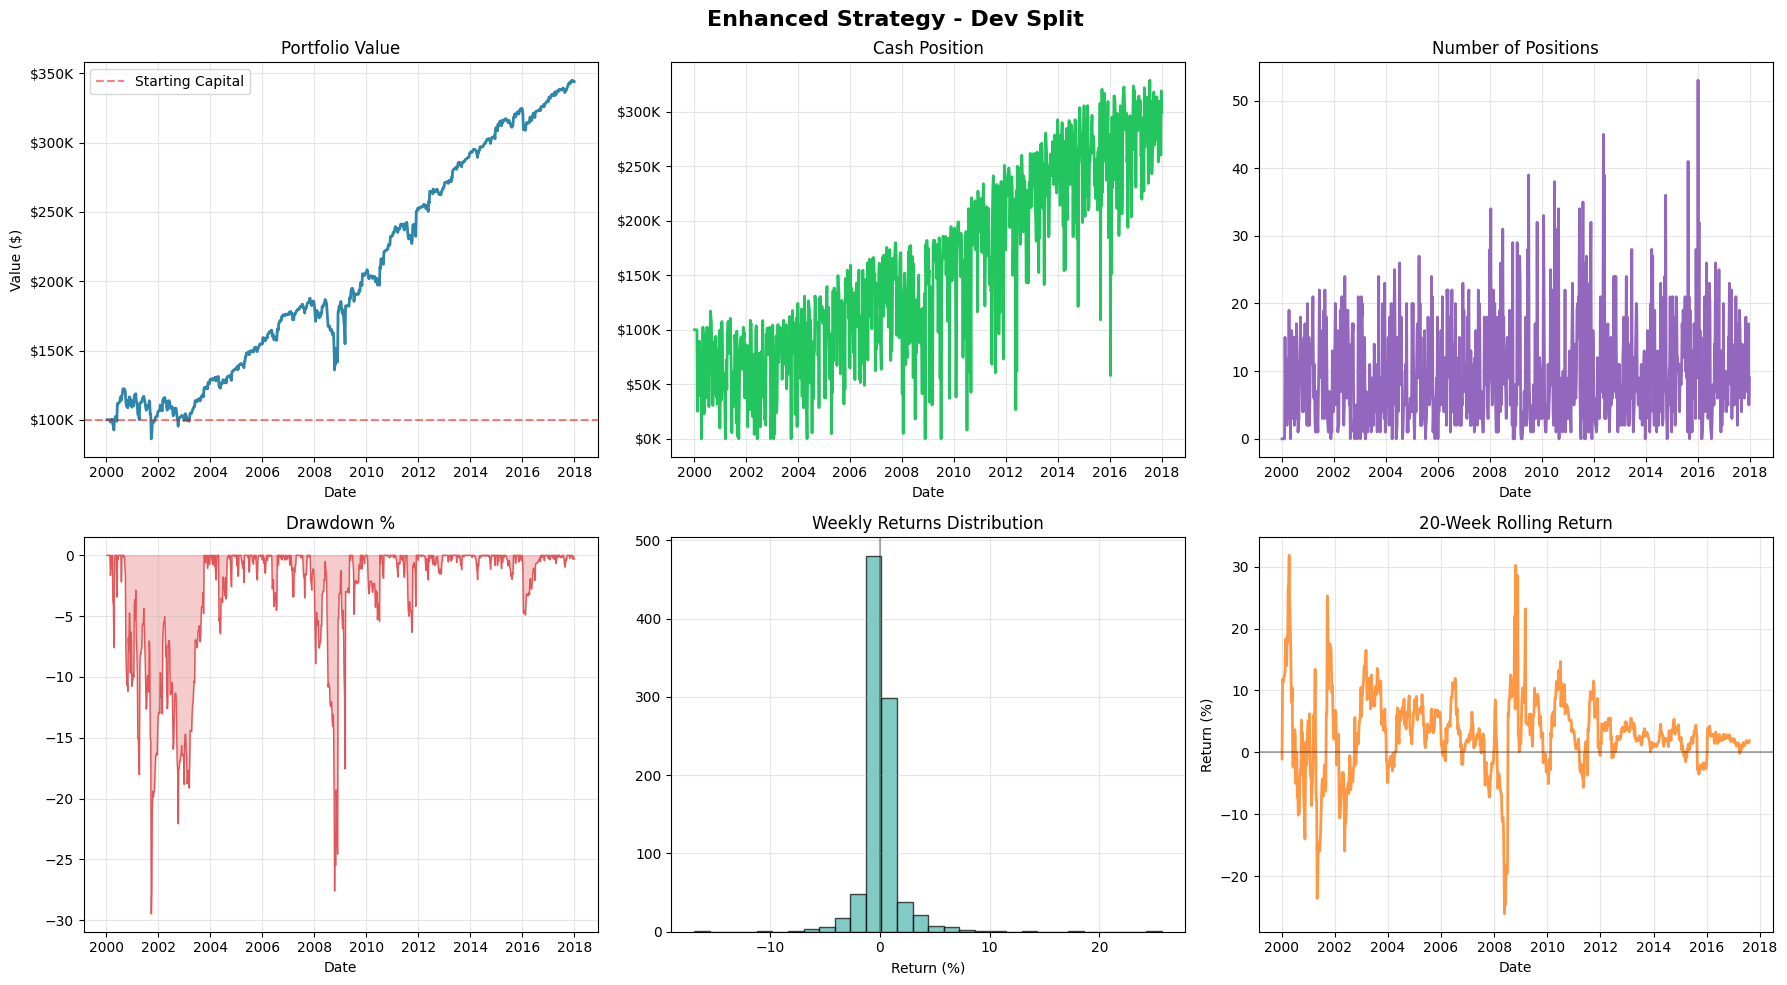


[VAL SPLIT - Final Performance]
Cleaning and preprocessing data...
Data ready: 598,740 price records
  [CACHE] Sim lookups loaded (val)
  Universe updated (2018-02): 68 stocks selected.
  Universe updated (2018-03): 68 stocks selected.
  Universe updated (2018-04): 69 stocks selected.
  Universe updated (2018-05): 68 stocks selected.
  Universe updated (2018-06): 68 stocks selected.
  Universe updated (2018-07): 68 stocks selected.
  Universe updated (2018-08): 68 stocks selected.
  Universe updated (2018-09): 69 stocks selected.
  Universe updated (2018-10): 68 stocks selected.
  Universe updated (2018-11): 69 stocks selected.
  Universe updated (2018-12): 68 stocks selected.
  Universe updated (2019-01): 68 stocks selected.
  Universe updated (2019-02): 69 stocks selected.
  Universe updated (2019-03): 68 stocks selected.
  Universe updated (2019-04): 68 stocks selected.
  Universe updated (2019-05): 68 stocks selected.
  Universe updated (2019-06): 68 stocks selected.
  Universe up

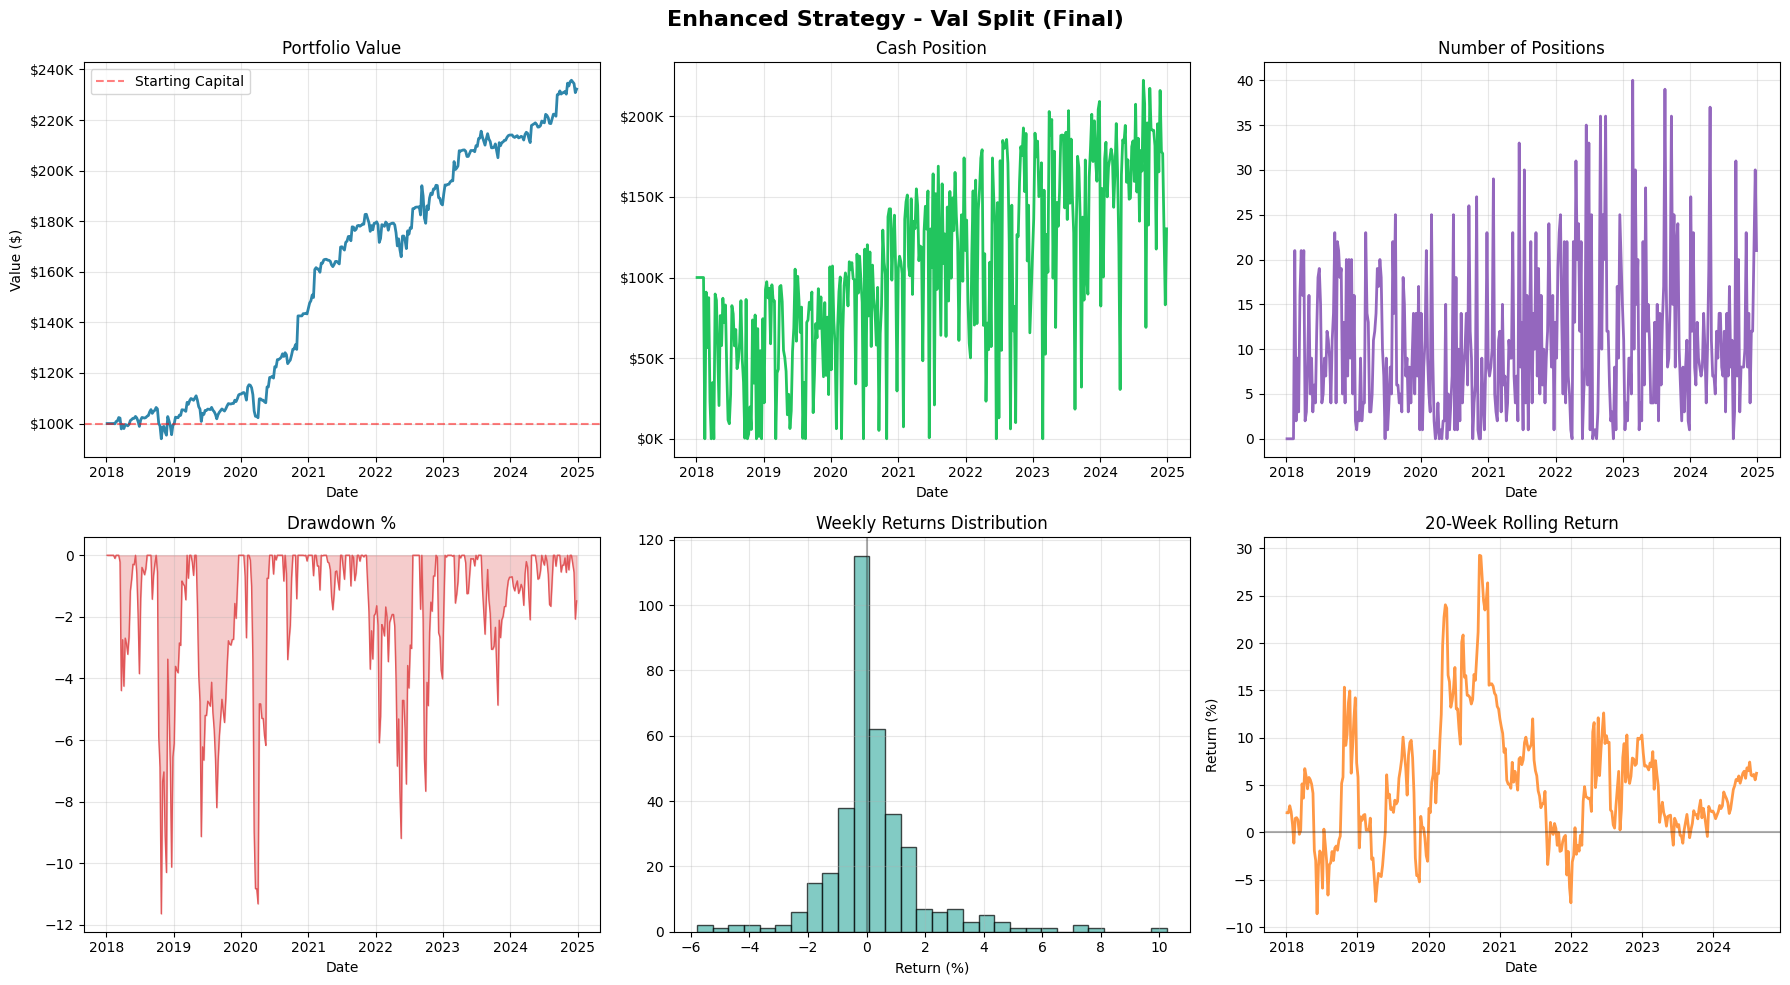

In [12]:
# ============================================================
# CELL 14: Enhanced Strategy Evaluation  (Cache-Aware)
# ============================================================
#
# INFRASTRUCTURE is cached to cache/ and only rebuilt when missing:
#   cache/analytics_{split}.parquet  — technical indicators
#   cache/lookup_{split}.pkl         — analytics lookup dict
#   cache/sim_lookups_{split}.pkl    — TradingSimulation price/earnings dicts
#
# The strategy itself always runs fresh on top of that infrastructure.
#
# To test a different strategy:
#   1. Swap the import in cell 9  OR  change the class definition in cell 10
#   2. Re-run this cell — only sim.run() executes (seconds, not minutes)
#
# To force a full infrastructure rebuild:
#   Delete the relevant files in cache/ and re-run.
#
# NOTE: analytics cache is shared across V6/V7/V8 (same columns).
#       If you switch to V3/V4/V5, delete cache/analytics_*.parquet first.
# ============================================================

import pandas as pd
from enhanced_helpers.lookups import build_analytics_lookup_vectorised

# ── Cache paths ───────────────────────────────────────────────────────────
_ANA_DEV = CACHE_DIR / 'analytics_dev.parquet'
_LKP_DEV = CACHE_DIR / 'lookup_dev.pkl'
_ANA_VAL = CACHE_DIR / 'analytics_val.parquet'
_LKP_VAL = CACHE_DIR / 'lookup_val.pkl'

# ── Helper: load + cache infrastructure for one split ─────────────────────
def _load_infra(split, ana_path, lkp_path):
    print(f'\n[{split.upper()}] Loading data...')
    prices   = load_prices(split)
    earnings = load_earnings(split)

    # Clean using a throw-away instance (fast, no FinBERT needed)
    _tmp = EnhancedStrategy(None)
    _tmp.prices, _tmp.earnings = _tmp.clean_data(prices, earnings)
    prices, earnings = _tmp.prices, _tmp.earnings

    if _cache_exists(ana_path, lkp_path):
        print(f'  [CACHE HIT]  Analytics ({split})')
        analytics = pd.read_parquet(ana_path)
        lookup    = _cache_load(lkp_path)
    else:
        print(f'  [CACHE MISS] Computing analytics ({split})...')
        analytics = _tmp.calculate_analytics(prices)
        lookup    = build_analytics_lookup_vectorised(analytics)
        analytics.to_parquet(ana_path, index=False)
        _cache_save(lookup, lkp_path)
        print(f'  Cached -> {ana_path.name}')

    # TradingSimulation with cached internal lookups (iterrows only runs once)
    print(f'  Building TradingSimulation ({split})...')
    sim_infra = TradingSimulation(prices, earnings, STARTING_CASH, cache_key=split)
    # We don't use sim_infra directly — just triggers the cache build
    del sim_infra

    return prices, earnings, analytics, lookup

# ── Build / load all infrastructure (runs fast after first time) ──────────
_prices_dev, _earnings_dev, _analytics_dev, _lookup_dev = _load_infra('dev', _ANA_DEV, _LKP_DEV)
_prices_val, _earnings_val, _analytics_val, _lookup_val = _load_infra('val', _ANA_VAL, _LKP_VAL)

print('\n' + '='*70)
print('Infrastructure ready. Running strategy...')
print('='*70)

# ============================================================
# DEV SPLIT
# ============================================================
print('\n[DEV SPLIT - Development / Tuning]')

enhanced_dev = EnhancedStrategy(finbert_pipeline)
enhanced_dev.set_data(_prices_dev, _earnings_dev)
enhanced_dev.universe_analytics_df = _analytics_dev  # inject cached analytics

# Fresh portfolio each run; sim lookups loaded from cache
sim_dev = TradingSimulation(_prices_dev, _earnings_dev, STARTING_CASH, cache_key='dev')
results_enhanced_dev = sim_dev.run(
    lambda t, d, tr, ps, a: enhanced_dev.make_decision(t, d, tr, ps, a),
    _lookup_dev
)

metrics_enhanced_dev = calculate_metrics(results_enhanced_dev)
ENHANCED_METRICS_DEV = {
    'return':    metrics_enhanced_dev['total_return'],
    'sharpe':    metrics_enhanced_dev['sharpe_ratio'],
    'drawdown':  metrics_enhanced_dev['max_drawdown'],
    'win_rate':  metrics_enhanced_dev['win_rate'],
    'volatility':metrics_enhanced_dev['volatility'],
    'trades':    metrics_enhanced_dev['num_trades'],
}

print(f"Return:       {ENHANCED_METRICS_DEV['return']:.2%}")
print(f"Sharpe Ratio: {ENHANCED_METRICS_DEV['sharpe']:.2f}")
print(f"Max Drawdown: {ENHANCED_METRICS_DEV['drawdown']:.2%}")
print(f"Win Rate:     {ENHANCED_METRICS_DEV['win_rate']:.1%}")
print(f"Volatility:   {ENHANCED_METRICS_DEV['volatility']:.2%}")
print(f"Total Trades: {ENHANCED_METRICS_DEV['trades']:,}")

plot_results(results_enhanced_dev, metrics_enhanced_dev, title='Enhanced Strategy - Dev Split')

# ============================================================
# VAL SPLIT
# ============================================================
print('\n[VAL SPLIT - Final Performance]')

enhanced_val = EnhancedStrategy(finbert_pipeline)
enhanced_val.set_data(_prices_val, _earnings_val)
enhanced_val.universe_analytics_df = _analytics_val  # inject cached analytics

sim_val = TradingSimulation(_prices_val, _earnings_val, STARTING_CASH, cache_key='val')
results_enhanced_val = sim_val.run(
    lambda t, d, tr, ps, a: enhanced_val.make_decision(t, d, tr, ps, a),
    _lookup_val
)

metrics_enhanced_val = calculate_metrics(results_enhanced_val)
ENHANCED_METRICS_VAL = {
    'return':    metrics_enhanced_val['total_return'],
    'sharpe':    metrics_enhanced_val['sharpe_ratio'],
    'drawdown':  metrics_enhanced_val['max_drawdown'],
    'win_rate':  metrics_enhanced_val['win_rate'],
    'volatility':metrics_enhanced_val['volatility'],
    'trades':    metrics_enhanced_val['num_trades'],
}

print(f"Return:       {ENHANCED_METRICS_VAL['return']:.2%}")
print(f"Sharpe Ratio: {ENHANCED_METRICS_VAL['sharpe']:.2f}")
print(f"Max Drawdown: {ENHANCED_METRICS_VAL['drawdown']:.2%}")

plot_results(results_enhanced_val, metrics_enhanced_val, title='Enhanced Strategy - Val Split (Final)')


In [13]:
# ============================================================
# CELL 15: Performance Comparison & Analysis
# ============================================================

# Once you've implemented and run your enhanced strategy (Cell 14),
# use the code below to compare performance against the baseline.

# The comparison functions are defined in Cell 8 and ready to use:
#   - plot_comparison(): Side-by-side visualizations
#   - print_detailed_comparison(): Detailed metrics table

# ============================================================
# USAGE EXAMPLES
# ============================================================
# Uncomment the code below once you have results from Cell 14

# print_detailed_comparison(BASELINE_METRICS_VAL, ENHANCED_METRICS_VAL)
# plot_comparison(results_baseline_val, metrics_baseline_val,
#                 results_enhanced_val, metrics_enhanced_val)